In [272]:
import pandas as pd
import warnings

from pandas.errors import SettingWithCopyWarning

warnings.filterwarnings("ignore", category=SettingWithCopyWarning)

In [282]:
def follow_diann_ids(
    diann_results,
    df_psms,
    q_value_column="spectrum_q",
    decoy_column="is_decoy",
    target_is_true=False,
    peptide_level=False,
):

    MODIFICATION_MAPPING = {
        "(UniMod:4)": "",
        "(UniMod:35)": "[Oxidation]",
    }
    # Make a copy to avoid modifying the original dataframe
    df_psms = df_psms.copy()

    for old, new in MODIFICATION_MAPPING.items():
        diann_results["Modified.Sequence"] = diann_results[
            "Modified.Sequence"
        ].str.replace(old, new, regex=False)
        diann_results["Precursor.Id"] = diann_results["Precursor.Id"].str.replace(
            old, new, regex=False
        )

    if decoy_column == "Label":
        # Decoy column mapping -1 to True, 1 to False
        df_psms[decoy_column] = df_psms[decoy_column].map({-1.0: True, 1.0: False})

    # Ensure the decoy column is boolean
    if df_psms[decoy_column].dtype != bool:
        df_psms[decoy_column] = df_psms[decoy_column].astype(bool)

    if not target_is_true:
        df_psms = df_psms[~df_psms[decoy_column]]
    else:
        df_psms = df_psms[df_psms[decoy_column]]

    if not peptide_level:
        # change modification naming in diann
        diann_results = diann_results.copy()

        try:
            df_psms["PrecursorID"] = df_psms["peptide"] + df_psms["charge"].astype(str)
        except KeyError:
            try:
                df_psms["PrecursorID"] = df_psms["Peptide"] + df_psms["Charge"].astype(
                    int
                ).astype(str)
            except KeyError:
                df_psms["PrecursorID"] = df_psms["Peptide"] + df_psms["charge"].astype(
                    int
                ).astype(str)

    df_psms_passing = df_psms[(df_psms[q_value_column] <= 0.01)]

    if not peptide_level:
        psm_set = set(df_psms["PrecursorID"])
        psm_passing_set = set(df_psms_passing["PrecursorID"])
        diann_set = set(diann_results["Precursor.Id"])
    else:
        psm_set = set(df_psms["peptide"])
        psm_passing_set = set(df_psms_passing["peptide"])
        diann_set = set(diann_results["Modified.Sequence"])

    common_ids = psm_set.intersection(diann_set)
    common_passing_ids = psm_passing_set.intersection(diann_set)
    in_diann_not_in_psm = diann_set - psm_set
    in_diann_not_in_psm_passing = diann_set - psm_passing_set

    print("Number of IDs in DIANN:", len(diann_set))
    print("Number of IDs in PSM (full):", len(psm_set))
    print("Number of IDs in PSM (passing):", len(psm_passing_set))
    print("\n")

    print("Number of common IDs (full):", len(common_ids))
    print("Number of common IDs (passing):", len(common_passing_ids))
    print("\n")

    print("Number of IDs in DIANN but not in PSM: (full)", len(in_diann_not_in_psm))
    print(
        "Number of IDs in DIANN but not in PSM (passing):",
        len(in_diann_not_in_psm_passing),
    )
    print("#" * 25)
    print("\n")

    return (
        common_ids,
        common_passing_ids,
        in_diann_not_in_psm,
        in_diann_not_in_psm_passing,
    )

In [274]:
diann_results = pd.read_parquet("/home/robbe/MuMDIA/DIA-NN_output/ecoli/report.parquet")

In [275]:
df_psms_full_search = pd.read_csv(
    "/home/robbe/MuMDIA/results/config_playing/df_psms.tsv", sep="\t"
)
# df_psms_before_mumdia = pd.read_csv(
#     "/home/robbe/MuMDIA/debug/df_psms_before_mumdia.tsv", sep="\t"
# )
# df_psms_before_rt = pd.read_csv(
#     "/home/robbe/MuMDIA/debug/df_psms_before_rt.tsv", sep="\t"
# )
# df_psms_after_rt = pd.read_csv(
#     "/home/robbe/MuMDIA/debug/df_psms_after_rt.tsv", sep="\t"
# )
# df_psms_after_retention_window_searches = pd.read_csv(
#     "/home/robbe/MuMDIA/debug/df_psms_after_retention_window_searches.tsv", sep="\t"
# )
# df_psms_after_ms2pip = pd.read_csv(
#     "/home/robbe/MuMDIA/debug/df_psms_after_ms2pip.tsv", sep="\t"
# )
# outfile = pd.read_csv(
#     "/home/robbe/MuMDIA/results/ecoli_debug_fragments_fixed/outfile.pin", sep="\t"
# )
# mokapot_psms = pd.read_csv(
#     "/home/robbe/MuMDIA/results/ecoli_debug_fragments_fixed/mokapot.psms.txt", sep="\t"
# )
#
# mokapot_merged = pd.merge(
#     mokapot_psms,
#     outfile[["ScanNr", "filename", "charge"]],
#     on=["filename", "ScanNr"],
#     how="left",
# )

In [276]:
df_psms_full_search

,psm_id,filename,scannr,peptide,stripped_peptide,proteins,num_proteins,rank,is_decoy,expmass,...,matched_intensity_pct,scored_candidates,poisson,sage_discriminant_score,posterior_error,spectrum_q,peptide_q,protein_q,reporter_ion_intensity,fragment_intensity
0,29153916,part_0.0_13829.432373046875.mzml,controllerType=0 controllerNumber=1 scan=159280,GYINSLGALTGGQALQQAK,GYINSLGALTGGQALQQAK,sp|P0A9G6|ACEA_ECOLI|63|82,1,3,False,1887.34410,...,57.802750,13118,-26.877016,0.625342,-324.000000,0.000010,0.000228,0.000233,NaN,5144217.000
1,28451612,part_0.0_13829.432373046875.mzml,controllerType=0 controllerNumber=1 scan=170519,APVIVQFSNGGASFIAGK,APVIVQFSNGGASFIAGK,sp|P0AB71|ALF_ECOLI|54|72,1,3,False,1767.28940,...,59.614174,10816,-28.842041,0.607864,-324.000000,0.000010,0.000228,0.000233,NaN,3195581.000
2,29768073,part_0.0_13829.432373046875.mzml,controllerType=0 controllerNumber=1 scan=170672,APVIVQFSNGGASFIAGK,APVIVQFSNGGASFIAGK,sp|P0AB71|ALF_ECOLI|54|72,1,3,False,1767.28940,...,59.278730,10892,-28.820402,0.607781,-324.000000,0.000010,0.000228,0.000233,NaN,2897112.000
3,4293154,part_0.0_13829.432373046875.mzml,controllerType=0 controllerNumber=1 scan=121859,LHGGEPANFLDVGGGATK,LHGGEPANFLDVGGGATK,sp|P0A836|SUCC_ECOLI|277|295,1,3,False,1735.27490,...,39.774796,5397,-31.002392,0.607150,-324.000000,0.000010,0.000228,0.000233,NaN,855111.500
4,29812921,part_0.0_13829.432373046875.mzml,controllerType=0 controllerNumber=1 scan=159357,GYINSLGALTGGQALQQAK,GYINSLGALTGGQALQQAK,sp|P0A9G6|ACEA_ECOLI|63|82,1,3,False,1895.34770,...,57.349964,12412,-26.988410,0.598553,-324.000000,0.000010,0.000228,0.000233,NaN,5340005.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11444058,19032195,part_0.0_13829.432373046875.mzml,controllerType=0 controllerNumber=1 scan=43462,REVPFSR,REVPFSR,rev_sp|P37024|HRPB_ECOLI|624|631,1,157,True,886.88930,...,1.364536,2640,-0.836371,-0.432501,-0.286703,0.958411,0.883353,0.890258,NaN,59675.117
11444059,10278711,part_0.0_13829.432373046875.mzml,controllerType=0 controllerNumber=1 scan=45370,DHGKLPR,DHGKLPR,sp|P75821|YBJS_ECOLI|330|337,1,174,False,814.85657,...,1.812451,2588,-0.836934,-0.432682,-0.286703,0.958411,1.000000,1.000000,NaN,7948.591
11444060,19930289,part_0.0_13829.432373046875.mzml,controllerType=0 controllerNumber=1 scan=43547,VRDIM[Oxidation]IPR,VRDIMIPR,sp|P0AE78|CORC_ECOLI|68|76,1,196,False,1022.95120,...,1.944821,3695,-0.836444,-0.432865,-0.286703,0.958411,0.917723,0.926266,NaN,26660.066
11444061,18255218,part_0.0_13829.432373046875.mzml,controllerType=0 controllerNumber=1 scan=116725,VIGTMKR,VIGTMKR,rev_sp|P0A976|CSPF_ECOLI|61|68;rev_sp|P0A982|C...,2,195,True,807.61017,...,0.184586,2778,-0.836748,-0.433067,-0.286703,0.958411,1.000000,0.927163,NaN,62217.117


In [277]:
psm_df_dict = {
    # "After Retention Window Searches": (
    #     df_psms_after_retention_window_searches,
    #     "spectrum_q",
    #     "is_decoy",
    #     False,
    # ),
    "Full search": (df_psms_full_search, "spectrum_q", "is_decoy", False),
    # "Before MuMDIA": (df_psms_before_mumdia, "spectrum_q", "is_decoy", False),
    # # "Before RT": (df_psms_before_rt, "spectrum_q", "is_decoy", False),
    # "After RT": (df_psms_after_rt, "spectrum_q", "is_decoy", False),
    # "After MS2PIP": (df_psms_after_ms2pip, "spectrum_q", "is_decoy", False),
    # "PIN": (outfile, "spectrum_q_min", "Label", False),
    # "Mokapot PSMS": (mokapot_merged, "mokapot q-value", "Label", True),
}

In [278]:
df_psms_full_search["rank"].unique()

array([  3,   1,   2,   6,   5,   4,   9,   8,   7,  12,  11,  10,  18,
        27,  16,  15,  17,  14,  78,  24,  64,  21,  13,  20, 197,  37,
        44,  48,  83,  95,  87,  33,  30,  89,  50,  42,  76,  58,  56,
        65,  35,  25,  40,  23,  29,  63,  31, 121, 124, 103,  38,  28,
        39, 139,  36,  32,  53,  84,  54,  70,  94,  60, 114,  77, 135,
        22,  90,  51,  57,  26,  61,  41,  19, 112, 155,  68, 109,  47,
       104,  52, 120, 110, 200, 150, 153,  97,  45, 127,  43,  73, 128,
       130,  59, 106, 178,  88,  49,  72, 115,  67, 163, 140,  85, 169,
        86, 137, 113,  46,  82, 148,  34, 164, 159, 165, 149, 145, 111,
       187, 184, 161,  98, 158, 134,  79,  91, 117, 196, 143, 156, 179,
        69, 102, 171, 131,  81, 186, 116,  55,  92, 180, 193, 183,  93,
        96, 108, 151, 138, 101,  66, 160, 132,  75, 185, 126, 198,  71,
       154,  80, 105, 176, 189, 170, 107,  62, 118, 147, 125,  99, 133,
       129, 123,  74, 146, 172, 190, 191, 177, 152, 194, 168, 14

In [279]:
diann_results

,Run.Index,Run,Channel,Precursor.Id,Modified.Sequence,Stripped.Sequence,Precursor.Charge,Precursor.Lib.Index,Decoy,Proteotypic,...,Translated.Q.Value,Channel.Q.Value,PG.Q.Value,PG.PEP,GG.Q.Value,Protein.Q.Value,Global.PG.Q.Value,Lib.PG.Q.Value,Best.Fr.Mz,Best.Fr.Mz.Delta
0,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAEIAVK2,AAAAEIAVK,AAAAEIAVK,2,10,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,317.218323,0.000641
1,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAPVTGPLADDPIQETITFDDFAK3,AAAAPVTGPLADDPIQETITFDDFAK,AAAAPVTGPLADDPIQETITFDDFAK,3,58,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,214.118622,0.001190
2,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAVLAK1,AAAAVLAK,AAAAVLAK,1,72,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,384.224152,-0.000183
3,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAADLISR2,AAADLISR,AAADLISR,2,107,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,603.346069,-0.000244
4,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAADVQLR2,AAADVQLR,AAADVQLR,2,116,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,701.394043,0.001038
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13971,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYLNAGVPIEIK2,YYLNAGVPIEIK,YYLNAGVPIEIK,2,712276,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,599.376282,0.000000
13972,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYPAEDAK2,YYPAEDAK,YYPAEDAK,2,712352,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,315.658295,0.000977
13973,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYPGSPLIAR2,YYPGSPLIAR,YYPGSPLIAR,2,712362,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,810.483215,0.007996
13974,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYQGTPSPVK2,YYQGTPSPVK,YYQGTPSPVK,2,712461,0,1,...,0.0,0.0,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,527.318787,0.000122


In [ ]:
for i, (name, args) in enumerate(psm_df_dict.items()):
    print(f"Processing DataFrame {i + 1}/{len(psm_df_dict)}: {name}")
    df_psm, q_value_column, decoy_column, target_is_true = args
    common_ids, common_passing_ids = follow_diann_ids(
        diann_results,
        df_psm,
        q_value_column=q_value_column,
        decoy_column=decoy_column,
        target_is_true=target_is_true,
    )

Processing DataFrame 1/1: Full search
Number of IDs in DIANN: 12112
Number of IDs in PSM (full): 205651
Number of IDs in PSM (passing): 7268


Number of common IDs (full): 11786
Number of common IDs (passing): 6448


Number of IDs in DIANN but not in PSM: (full) 326
Number of IDs in DIANN but not in PSM (passing): 5664
#########################




In [281]:
in_diann_not_in

{'ACDGCLNGEFAALITGPVHK',
 'ACDLVLK',
 'ACEEVGFVSR',
 'ADITLISGSTLGGAEYVAEHLAEK',
 'ADM[Oxidation]HYIIR',
 'AEETIFSK',
 'AEFPASLLILNGK',
 'AEITASLVK',
 'AENQYYGTGR',
 'AESFTTTNR',
 'AFCEPGK',
 'AFICSIK',
 'AFTPFPPR',
 'AGNTIGQLFR',
 'AIALVTGGSR',
 'AIEQTAITR',
 'AIPAFGLGTFR',
 'AITGIFFGSDTGNTENIAK',
 'ALLQISEPGLSAAPHQR',
 'ALNLQDK',
 'ANKPSAEELK',
 'ANPEQLEEQR',
 'ANPEQLEEQREETR',
 'ANPLYQK',
 'ANPTVIK',
 'ANSITADEIR',
 'ANVEIYTK',
 'ANYFNTLNLR',
 'AQFVYTM[Oxidation]HR',
 'AQGTLYIVSAPSGAGK',
 'AQIFNFSSGPAMLPAEVLK',
 'AQIFNFSSGPAM[Oxidation]LPAEVLK',
 'AQPAAIIR',
 'AQQSPYSAAM[Oxidation]AEQR',
 'AQQTPLYEQHTLCGAR',
 'AQVAIITASDSGIGK',
 'ASVQLQNVTK',
 'ATIHVDGK',
 'ATVNQLVR',
 'ATYYSNDFR',
 'AVTNVAELNALVER',
 'AVTQTAQACDLVIFGAK',
 'AYQSQDIIR',
 'AYTTFSQTK',
 'CCSDVFNQVVK',
 'CDSCGQVLYR',
 'CGIVGAIAQR',
 'CQEVIDR',
 'CSFLPEER',
 'CTEEHQAIVR',
 'CTQELLFGK',
 'DAFIDEM[Oxidation]QR',
 'DALELLINR',
 'DCFALECEAVK',
 'DCVVVVR',
 'DECGCGESFHV',
 'DFDDAVYCEK',
 'DFNSYGSR',
 'DFSAQVLR',
 'DHHVDVTYK',

In [290]:
# Plot a histogram of the q-values of DIA-NN IDs with whether the IDs are either not in the identified MuMDIA PSMs, found but not passing FDR, or found and passing FDR
import matplotlib.pyplot as plt

# Use common_ids to flag in diann_results. If in common_ids, give flag "Present"
# First, set all to "Not Present"
diann_results["in_mumdia"] = "Not Present"

# Then, set "Present and Passing FDR" for those in common_passing_ids
diann_results.loc[
    diann_results["Modified.Sequence"].isin(common_passing_ids), "in_mumdia"
] = "Present and Passing FDR"

# Next, set "Present" for those in common_ids but not in common_passing_ids
diann_results.loc[
    diann_results["Modified.Sequence"].isin(common_ids)
    & ~diann_results["Modified.Sequence"].isin(common_passing_ids),
    "in_mumdia",
] = "Present"

In [291]:
diann_results

,Run.Index,Run,Channel,Precursor.Id,Modified.Sequence,Stripped.Sequence,Precursor.Charge,Precursor.Lib.Index,Decoy,Proteotypic,...,PG.Q.Value,PG.PEP,GG.Q.Value,Protein.Q.Value,Global.PG.Q.Value,Lib.PG.Q.Value,Best.Fr.Mz,Best.Fr.Mz.Delta,in_mumdia,logqvalue
0,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAEIAVK2,AAAAEIAVK,AAAAEIAVK,2,10,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,317.218323,0.000641,Present and Passing FDR,6.001258
1,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAPVTGPLADDPIQETITFDDFAK3,AAAAPVTGPLADDPIQETITFDDFAK,AAAAPVTGPLADDPIQETITFDDFAK,3,58,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,214.118622,0.001190,Present,6.001258
2,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAVLAK1,AAAAVLAK,AAAAVLAK,1,72,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,384.224152,-0.000183,Present,2.603990
3,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAADLISR2,AAADLISR,AAADLISR,2,107,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,603.346069,-0.000244,Present and Passing FDR,6.001258
4,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAADVQLR2,AAADVQLR,AAADVQLR,2,116,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,701.394043,0.001038,Present and Passing FDR,5.909918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13971,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYLNAGVPIEIK2,YYLNAGVPIEIK,YYLNAGVPIEIK,2,712276,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,599.376282,0.000000,Present and Passing FDR,6.001258
13972,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYPAEDAK2,YYPAEDAK,YYPAEDAK,2,712352,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,315.658295,0.000977,Present and Passing FDR,6.001258
13973,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYPGSPLIAR2,YYPGSPLIAR,YYPGSPLIAR,2,712362,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,810.483215,0.007996,Present,2.238207
13974,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYQGTPSPVK2,YYQGTPSPVK,YYQGTPSPVK,2,712461,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,527.318787,0.000122,Present and Passing FDR,4.544427


In [292]:
import numpy as np

diann_results["logqvalue"] = -np.log10(diann_results["Q.Value"])

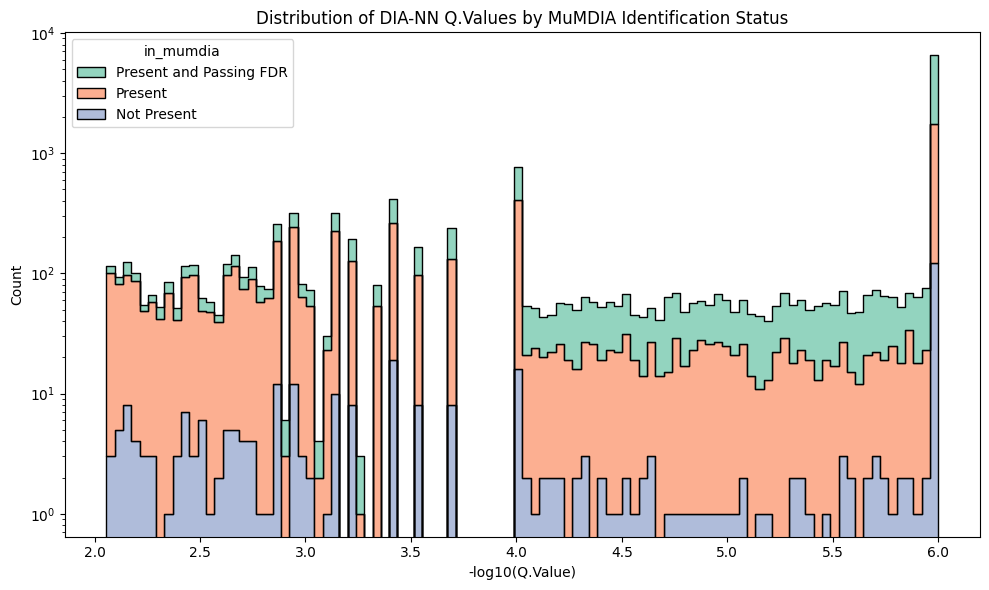

In [293]:
import seaborn as sns

# Plot q-values of diann_results, hued by in_mumdia
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(
    data=diann_results,
    x="logqvalue",
    hue="in_mumdia",
    bins=100,
    element="step",
    stat="count",
    common_norm=False,
    palette="Set2",
    alpha=0.7,
    multiple="stack",
)

# plt.xscale("log")
plt.yscale("log")
plt.xlabel("-log10(Q.Value)")
plt.ylabel("Count")
plt.title("Distribution of DIA-NN Q.Values by MuMDIA Identification Status")
plt.tight_layout()
plt.show()

In [158]:
diann_results

,Run.Index,Run,Channel,Precursor.Id,Modified.Sequence,Stripped.Sequence,Precursor.Charge,Precursor.Lib.Index,Decoy,Proteotypic,...,PG.Q.Value,PG.PEP,GG.Q.Value,Protein.Q.Value,Global.PG.Q.Value,Lib.PG.Q.Value,Best.Fr.Mz,Best.Fr.Mz.Delta,in_mumdia,logqvalue
0,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAEIAVK2,AAAAEIAVK,AAAAEIAVK,2,10,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,317.218323,0.000641,Present and Passing FDR,6.001258
1,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAPVTGPLADDPIQETITFDDFAK3,AAAAPVTGPLADDPIQETITFDDFAK,AAAAPVTGPLADDPIQETITFDDFAK,3,58,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,214.118622,0.001190,Present,6.001258
2,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAAAVLAK1,AAAAVLAK,AAAAVLAK,1,72,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,384.224152,-0.000183,Present,2.603990
3,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAADLISR2,AAADLISR,AAADLISR,2,107,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,603.346069,-0.000244,Present and Passing FDR,6.001258
4,0,LFQ_Orbitrap_AIF_Ecoli_01,,AAADVQLR2,AAADVQLR,AAADVQLR,2,116,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,701.394043,0.001038,Present and Passing FDR,5.909918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13971,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYLNAGVPIEIK2,YYLNAGVPIEIK,YYLNAGVPIEIK,2,712276,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,599.376282,0.000000,Present and Passing FDR,6.001258
13972,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYPAEDAK2,YYPAEDAK,YYPAEDAK,2,712352,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,315.658295,0.000977,Present and Passing FDR,6.001258
13973,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYPGSPLIAR2,YYPGSPLIAR,YYPGSPLIAR,2,712362,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,810.483215,0.007996,Not Present,2.238207
13974,0,LFQ_Orbitrap_AIF_Ecoli_01,,YYQGTPSPVK2,YYQGTPSPVK,YYQGTPSPVK,2,712461,0,1,...,0.000646,0.001287,0.00065,0.000651,0.000646,0.0,527.318787,0.000122,Present and Passing FDR,4.544427
